# DS 450 Visualization
**Sebastian Vargas**

---

My goal for this project is to create a **stacked bar chart** of **frequencies of actions following inspections over time**. With a particular focus on **closures**, **re-closures**, and **re-openings**. This will be an opportunity to demo some rudimentary visualizations before building the interactive model. First we open the CSV file with the data we need.

In [1]:
import pandas as pd

# Read the CSV
df = pd.read_csv("DOHMH_New_York_City_Restaurant_Inspection_Results_20260501.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296749 entries, 0 to 296748
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296749 non-null  int64  
 1   DBA                    296747 non-null  object 
 2   BORO                   296749 non-null  object 
 3   BUILDING               295771 non-null  object 
 4   STREET                 296734 non-null  object 
 5   ZIPCODE                293584 non-null  float64
 6   PHONE                  296669 non-null  object 
 7   CUISINE DESCRIPTION    293176 non-null  object 
 8   INSPECTION DATE        296749 non-null  object 
 9   ACTION                 293272 non-null  object 
 10  VIOLATION CODE         290909 non-null  object 
 11  VIOLATION DESCRIPTION  290909 non-null  object 
 12  CRITICAL FLAG          296749 non-null  object 
 13  SCORE                  279670 non-null  float64
 14  GRADE                  146159 non-nu

For my visualization the primary columns I am going to be dealing with are the `ACTION` column and the `INSPECTION DATE` columns. First we need to see what the possible values are for actions:

In [4]:
actions = df['ACTION']
actions.describe()

count                                              293272
unique                                                  5
top       Violations were cited in the following area(s).
freq                                               277252
Name: ACTION, dtype: object

In [5]:
actions.value_counts()

ACTION
Violations were cited in the following area(s).                                                                                       277252
Establishment Closed by DOHMH. Violations were cited in the following area(s) and those requiring immediate action were addressed.     10666
No violations were recorded at the time of this inspection.                                                                             2306
Establishment re-opened by DOHMH.                                                                                                       1764
Establishment re-closed by DOHMH.                                                                                                       1284
Name: count, dtype: int64

In particular we are interested in the following specific action types:

 - Establishment Closed by DOHMH.
 - Establishment re-opened by DOHMH.
 - Establishment re-closed by DOHMH.

I'll start by constructing a copy of the dataframe with only the columns I need, and build it into the features I need.

In [18]:
df_filtered = df[['CAMIS', 'INSPECTION DATE', 'ACTION']].copy()
df_filtered['INSPECTION DATE'] = pd.to_datetime(df_filtered['INSPECTION DATE'])
df_filtered['INSPECTION YEAR'] = df_filtered['INSPECTION DATE'].dt.year
df_filtered.head(5)

,CAMIS,INSPECTION DATE,ACTION,INSPECTION YEAR
0,50184964,1900-01-01,NaN,1900
1,50143076,2024-02-07,Violations were cited in the following area(s).,2024
2,50159201,1900-01-01,NaN,1900
3,50181083,1900-01-01,NaN,1900
4,50175841,1900-01-01,NaN,1900


Now that I've filtered the columns I needed I'm going to filter out rows in which the action is NaN

In [20]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296749 entries, 0 to 296748
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   CAMIS            296749 non-null  int64         
 1   INSPECTION DATE  296749 non-null  datetime64[ns]
 2   ACTION           293272 non-null  object        
 3   INSPECTION YEAR  296749 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(1)
memory usage: 7.9+ MB


In [22]:
df_filtered.dropna(subset=['ACTION'], inplace=True)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293272 entries, 1 to 296748
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   CAMIS            293272 non-null  int64         
 1   INSPECTION DATE  293272 non-null  datetime64[ns]
 2   ACTION           293272 non-null  object        
 3   INSPECTION YEAR  293272 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(1), object(1)
memory usage: 10.1+ MB


In [23]:
mapping = {
    "Establishment Closed by DOHMH. Violations were cited in the following area(s) and those requiring immediate action were addressed.": 0,
    "Establishment re-closed by DOHMH.": 1,
    "Establishment re-opened by DOHMH.": 2,
    "Violations were cited in the following area(s).": 3,
    "No violations were recorded at the time of this inspection.": 3
}

df_filtered['ACTION CLASS'] = df_filtered['ACTION'].map(mapping)

In [29]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293272 entries, 1 to 296748
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   CAMIS            293272 non-null  int64         
 1   INSPECTION DATE  293272 non-null  datetime64[ns]
 2   ACTION           293272 non-null  object        
 3   INSPECTION YEAR  293272 non-null  int32         
 4   ACTION CLASS     293272 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(2), object(1)
memory usage: 12.3+ MB


In [28]:
df_filtered[df_filtered['ACTION CLASS'] == 0].head(5)

,CAMIS,INSPECTION DATE,ACTION,INSPECTION YEAR,ACTION CLASS
1011,50106463,2024-08-02,Establishment Closed by DOHMH. Violations were...,2024,0
1017,50117697,2024-11-15,Establishment Closed by DOHMH. Violations were...,2024,0
1037,50163424,2025-10-21,Establishment Closed by DOHMH. Violations were...,2025,0
1053,50067930,2017-09-18,Establishment Closed by DOHMH. Violations were...,2017,0
1069,50127340,2024-07-17,Establishment Closed by DOHMH. Violations were...,2024,0


with this we can make a preliminary stacked bar chart for all years demonstrating frequencies of different action classes. We just have to reformat the dataframe.

In [31]:
table = (
    df_filtered
    .groupby(['INSPECTION YEAR', 'ACTION CLASS'])
    .size()
    .unstack(fill_value=0)
)
table

ACTION CLASS,0,1,2,3
INSPECTION YEAR,,,,
2007,0,0,0,51
2008,12,0,1,32
2009,0,0,0,4
2010,0,0,0,13
2011,0,0,0,6
2012,0,0,0,6
2013,0,0,0,2
2014,0,0,0,12
2015,0,0,1,32


Interestingly there is a lack of closures, reclosures, and reopenings between 2007 and 2021 which might be indicative of no tracking or something else. 

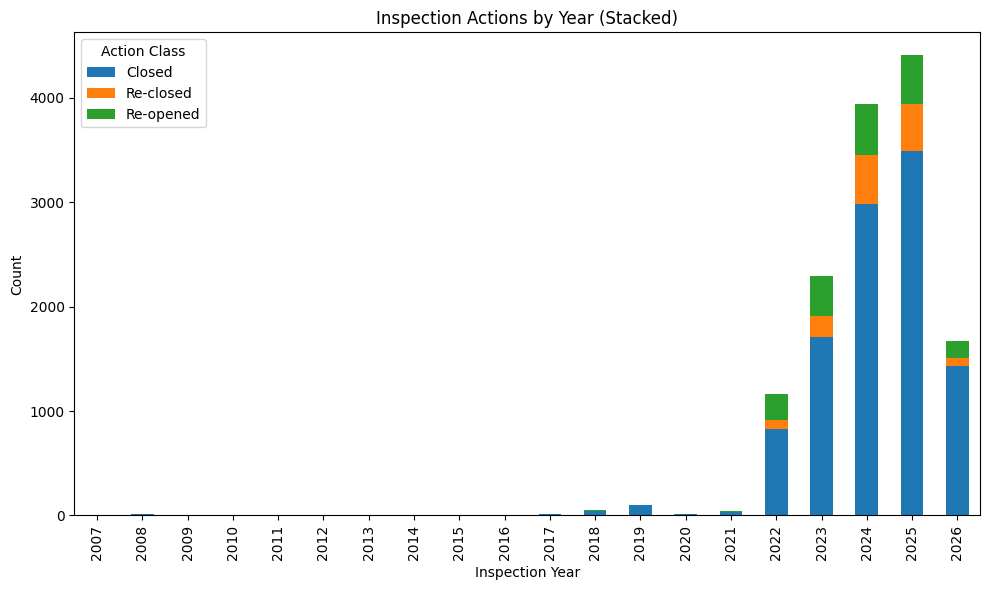

In [32]:
import matplotlib.pyplot as plt

plot_df = table.drop(columns=3, errors='ignore')

plot_df = plot_df.rename(columns={
    0: 'Closed',
    1: 'Re-closed',
    2: 'Re-opened'
})

plot_df.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.xlabel('Inspection Year')
plt.ylabel('Count')
plt.title('Inspection Actions by Year (Stacked)')
plt.legend(title='Action Class')
plt.tight_layout()
plt.show()

This is functionally what we want in the visualization so I will translate this into an interactable visualization.